In [1]:
import numpy as np
from numpy import pi, arccos, cos, sin, tan, mean
import matplotlib.pyplot as plt
from cats.cdataframe import CDataFrame
import glob
import pandas as pd
from matplotlib.lines import Line2D

Welcome to JupyROOT 6.28/10


In [2]:
h     = 4.13566e-12 # MeV*ns
hbar  = h / (2 * np.pi) # MeV*ns
mass = {'h': 0.50 * 0.51099906 / (2.99792458 * 1e2)**2,
        'e': 1.4672e-6} # MeV ns^2 / mm^2
vsound = 0.009 # mm/ns # Longitudinal sound speed

ksound = {'h': mass['h'] * vsound / hbar,
          'e': mass['e'] * vsound / hbar}

lss = {'G4CMPLukeScattering': '-',
       'CoupledTransportation': '--',
       'G4CMPTimeStepper': 'dotted'}

In [3]:
colors = {'4V': {'h': '#D72B22',
                 'e': '#FC8D57'},
          '0V': {'h': '#3D6CA5',
                   'e': '#92C0DC'}}

label = {'0V': {'h': r'$\mathbf{holes}$ at $\mathbf{0V}$',
                 'e': r'$\mathbf{electrons}$ at $\mathbf{0V}$'},
          '4V': {'h': r'$\mathbf{holes}$ at $\mathbf{4V}$',
                   'e': r'$\mathbf{electrons}$ at $\mathbf{4V}$'}}

In [4]:
Vs = ['0V', '4V']
charges = ['h', 'e']

DMC_filenames = {V: {charge: sorted(glob.glob(f'/scratch/group/mitchcomp/CDMS/data/perry5334/MSC_NTLemission_samples/{charge}_{V}_new/stepcounter_5124????_0000??.root')) for charge in charges} for V in Vs}

Debug_filenames = {V: {charge: sorted(glob.glob(f'/scratch/group/mitchcomp/CDMS/data/perry5334/MSC_NTLemission_samples/{charge}_{V}_new/LukePhononEnergies_?')) + 
                    sorted(glob.glob(f'/scratch/group/mitchcomp/CDMS/data/perry5334/MSC_NTLemission_samples/{charge}_{V}_new/LukePhononEnergies_??')) for charge in charges} for V in Vs}

In [5]:
parameters = (['EventNum', 'KE', 'KE3', 'Process', 'Charge', 'PName', 'TrkStep', 'Parent', 'Weight'] + 
              [label + sequence for sequence in ['1', '3'] for label in ['X', 'Y', 'Z', 'Xmom', 'Ymom', 'Zmom', 'Time', 'V']])

data = {V: {charge: None for charge in charges} for V in Vs}

for V in Vs:
    for charge in charges:
        mcHitCounter = CDataFrame('G4SimDir/mcHitCounter', DMC_filenames[V][charge])
        data[V][charge] = mcHitCounter.AsNumpy(parameters)
        data[V][charge]['eCut'] = (data[V][charge]['Charge'] == -1) & (data[V][charge]['Process'] == 'G4CMPLukeScattering')
        data[V][charge]['hCut'] = (data[V][charge]['Charge'] == 1) & (data[V][charge]['Process'] == 'G4CMPLukeScattering')
        data[V][charge]['phCut'] = (data[V][charge]['Charge'] == 0) & (data[V][charge]['TrkStep']%100000==1)

In [6]:
def merge(X1, X3):
    return np.concatenate([[X1[i], X3[i]] for i in range(len(X1))])

(-0.0025, 0.005)

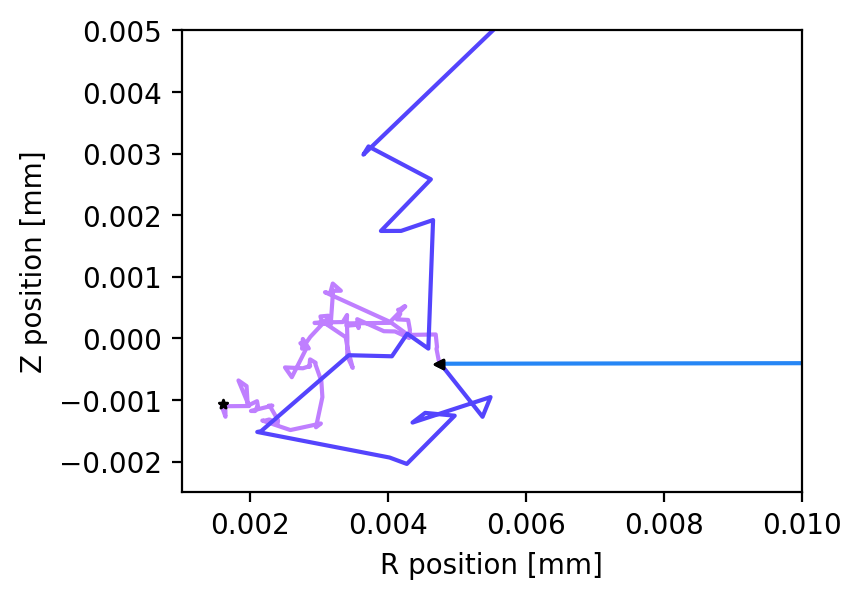

In [22]:
V = '0V'
charge = 'h'
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.rainbow(np.linspace(0,0.8,10)))

plt.figure(figsize = (4,3), dpi=200)
nphonons = 0
for event in np.unique(data[V][charge]['EventNum'])[:1]:
    eventCut = data[V][charge]['EventNum'] == event
    hCut = data[V][charge]['hCut']
    phCut = data[V][charge]['Charge'] == 0
    X1, Y1, Z1 = data[V][charge]['X1'], data[V][charge]['Y1'], data[V][charge]['Z1']
    X3, Y3, Z3 = data[V][charge]['X3'], data[V][charge]['Y3'], data[V][charge]['Z3']
    Rs = np.sqrt(merge(X1[eventCut & hCut], X3[eventCut & hCut]) ** 2 + merge(Y1[eventCut & hCut], Y3[eventCut & hCut]) ** 2)
    Zs = merge(Z1[eventCut & hCut], Z3[eventCut & hCut])
    plt.scatter([Rs[1:2]*1e3], [Zs[1:2]*1e3], color = 'black', marker = '*', zorder = 1000, s = 10)

    for time in data[V][charge]['Time3'][hCut & eventCut][:1]:
        emissionCut = abs(data[V][charge]['Time1'] - time) < 1e-9
        TrkStep = data[V][charge]['TrkStep'][emissionCut & phCut & eventCut]
        TrkCut = data[V][charge]['TrkStep'] // 100000 == TrkStep // 100000
        Rs = np.sqrt(merge(X1[eventCut & phCut & TrkCut], X3[eventCut & phCut & TrkCut]) ** 2 + merge(Y1[eventCut & phCut & TrkCut], Y3[eventCut & phCut & TrkCut]) ** 2)
        Zs = merge(Z1[eventCut & phCut & TrkCut], Z3[eventCut & phCut & TrkCut])
        KE = data[V][charge]['KE'][eventCut & phCut & TrkCut]
        Tdiff = data[V][charge]['Time3'][eventCut & phCut & TrkCut][-1] - data[V][charge]['Time1'][eventCut & phCut & TrkCut][0]
        plt.plot(Rs*1e3, Zs*1e3, alpha = 0.5)

        timeCut = abs(data[V][charge]['Time1'] - data[V][charge]['Time3'][eventCut & phCut & TrkCut][-1]) < 1e-9
        nphonons = 1
        while any(timeCut):
            decayTrks = data[V][charge]['TrkStep'][timeCut & phCut & eventCut] // 100000
            timeCut = np.full(len(data[V][charge]['Time1']), False)
            for Trk in decayTrks:
                TrkCut = data[V][charge]['TrkStep'] // 100000 == Trk
                Rs = np.sqrt(merge(X1[eventCut & phCut & TrkCut], X3[eventCut & phCut & TrkCut]) ** 2 + merge(Y1[eventCut & phCut & TrkCut], Y3[eventCut & phCut & TrkCut]) ** 2)
                Zs = merge(Z1[eventCut & phCut & TrkCut], Z3[eventCut & phCut & TrkCut])
                T3 = data[V][charge]['Time3'][eventCut & phCut & TrkCut][-1]
                timeCut = timeCut | (abs(data[V][charge]['Time1'] - T3) < 1e-9)
                if abs(Zs[0] - 0.0019994) < 1e-5:
                    continue
                nphonons += 1
                plt.scatter([Rs[0]*1e3], [Zs[0]*1e3], color = 'black', marker = '<', zorder = 1000, s = 10)
                plt.plot(Rs*1e3, Zs*1e3)

plt.xlabel(r'R position [mm]')
plt.ylabel(r'Z position [mm]')
plt.xlim(0.001, 0.01)
plt.ylim(-0.0025, 0.005)

(-2.5, 5.0)

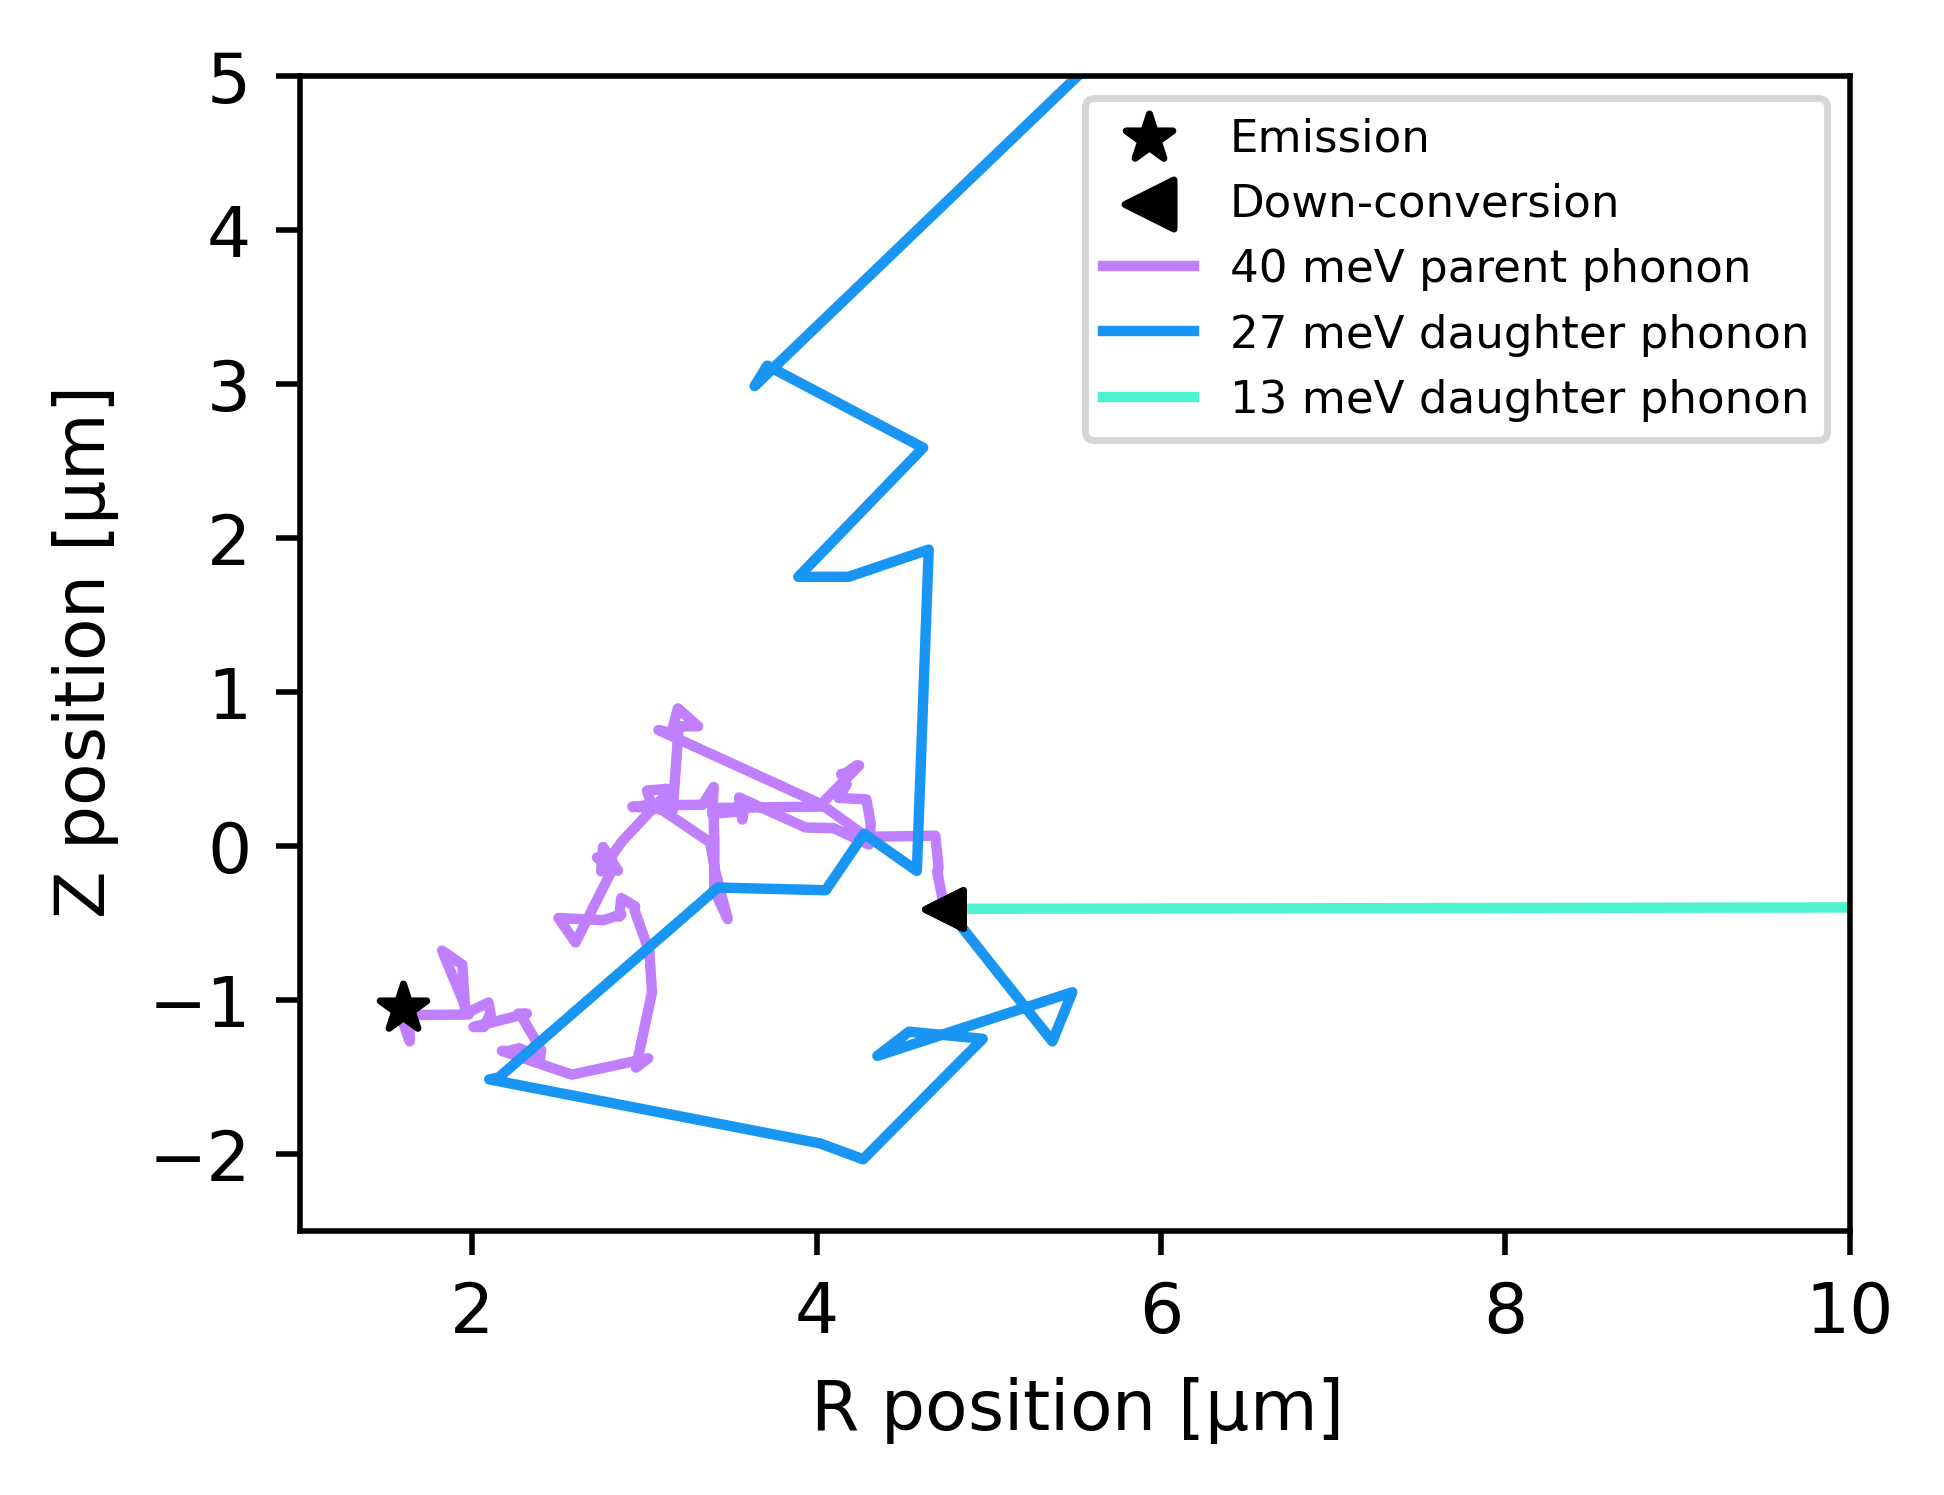

In [58]:
V = '0V'
charge = 'h'
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.rainbow(np.linspace(0,1,6)))

plt.figure(figsize = (4,3), dpi=500)
nphonons = 0
for event in np.unique(data[V][charge]['EventNum'])[:1]:
    eventCut = data[V][charge]['EventNum'] == event
    hCut = data[V][charge]['hCut']
    phCut = data[V][charge]['Charge'] == 0
    X1, Y1, Z1 = data[V][charge]['X1'], data[V][charge]['Y1'], data[V][charge]['Z1']
    X3, Y3, Z3 = data[V][charge]['X3'], data[V][charge]['Y3'], data[V][charge]['Z3']
    Rs = np.sqrt(merge(X1[eventCut & hCut], X3[eventCut & hCut]) ** 2 + merge(Y1[eventCut & hCut], Y3[eventCut & hCut]) ** 2)
    Zs = merge(Z1[eventCut & hCut], Z3[eventCut & hCut])
    plt.scatter([Rs[1:2]*1e6], [Zs[1:2]*1e6], color = 'black', marker = '*', zorder = 1000, s = 50, label = 'Emission')
    plt.scatter([-1000], [-1000], color = 'black', marker = '<', zorder = 1000, s = 50, label = 'Down-conversion')
    #plt.plot([Rs*1e6], [Zs*1e6], color = 'black', ls = '--', lw = 1)

    for time in data[V][charge]['Time3'][hCut & eventCut][:1]:
        emissionCut = abs(data[V][charge]['Time1'] - time) < 1e-9
        TrkStep = data[V][charge]['TrkStep'][emissionCut & phCut & eventCut]
        TrkCut = data[V][charge]['TrkStep'] // 100000 == TrkStep // 100000
        Rs = np.sqrt(merge(X1[eventCut & phCut & TrkCut], X3[eventCut & phCut & TrkCut]) ** 2 + merge(Y1[eventCut & phCut & TrkCut], Y3[eventCut & phCut & TrkCut]) ** 2)
        Zs = merge(Z1[eventCut & phCut & TrkCut], Z3[eventCut & phCut & TrkCut])
        KE = data[V][charge]['KE'][eventCut & phCut & TrkCut][0]
        Tdiff = data[V][charge]['Time3'][eventCut & phCut & TrkCut][-1] - data[V][charge]['Time1'][eventCut & phCut & TrkCut][0]
        plt.plot(Rs*1e6, Zs*1e6, alpha = 0.5, label = f'{int(np.round(KE*1e3))} meV parent phonon')

        timeCut = abs(data[V][charge]['Time1'] - data[V][charge]['Time3'][eventCut & phCut & TrkCut][-1]) < 1e-9
        nphonons = 1
        #while any(timeCut):
        if any(timeCut):
            decayTrks = data[V][charge]['TrkStep'][timeCut & phCut & eventCut] // 100000
            timeCut = np.full(len(data[V][charge]['Time1']), False)
            for Trk in decayTrks:
                TrkCut = data[V][charge]['TrkStep'] // 100000 == Trk
                Rs = np.sqrt(merge(X1[eventCut & phCut & TrkCut], X3[eventCut & phCut & TrkCut]) ** 2 + merge(Y1[eventCut & phCut & TrkCut], Y3[eventCut & phCut & TrkCut]) ** 2)
                Zs = merge(Z1[eventCut & phCut & TrkCut], Z3[eventCut & phCut & TrkCut])
                T3 = data[V][charge]['Time3'][eventCut & phCut & TrkCut][-1]
                KE = data[V][charge]['KE'][eventCut & phCut & TrkCut][0]
                timeCut = timeCut | (abs(data[V][charge]['Time1'] - T3) < 1e-9)
                if abs(Zs[0] - 0.0019994) < 1e-5:
                    continue
                nphonons += 1
                plt.scatter([Rs[0]*1e6], [Zs[0]*1e6], color = 'black', marker = '<', zorder = 1000, s = 30)
                plt.plot(Rs*1e6, Zs*1e6, label = f'{int(np.round(KE*1e3))} meV daughter phonon')

plt.xlabel(r'R position [$\mathrm{\mu m}$]')
plt.ylabel(r'Z position [$\mathrm{\mu m}$]')
plt.legend(fontsize = 6.5, loc = 'upper right')
plt.xlim(1, 10)
plt.ylim(-2.5, 5)

In [49]:
V = '4V'
charge = 'h'
phononstepstot, chargestepstot = 0, 0
for event in np.unique(data[V][charge]['EventNum'])[:1]:
    eventCut = data[V][charge]['EventNum'] == event
    hCut = data[V][charge]['hCut']
    phCut = data[V][charge]['Charge'] == 0
    X1, Y1, Z1 = data[V][charge]['X1'], data[V][charge]['Y1'], data[V][charge]['Z1']
    X3, Y3, Z3 = data[V][charge]['X3'], data[V][charge]['Y3'], data[V][charge]['Z3']
    print("Charge Step","| Number of Phonons","| Number of Phonon Steps")
    chargestepstot = len(data[V][charge]['Time3'][hCut & eventCut])
    for time in data[V][charge]['Time3'][hCut & eventCut]:
        emissionCut = abs(data[V][charge]['Time1'] - time) < 1e-9
        TrkStep = data[V][charge]['TrkStep'][emissionCut & phCut & eventCut]
        TrkCut = data[V][charge]['TrkStep'] // 100000 == TrkStep // 100000
        Tdiff = data[V][charge]['Time3'][eventCut & phCut & TrkCut][-1] - data[V][charge]['Time1'][eventCut & phCut & TrkCut][0]

        timeCut = abs(data[V][charge]['Time1'] - data[V][charge]['Time3'][eventCut & phCut & TrkCut][-1]) < 1e-9
        nphonons = 1
        nphononsteps = len(data[V][charge]['Time3'][eventCut & phCut & TrkCut])
        while any(timeCut):
            decayTrks = data[V][charge]['TrkStep'][timeCut & phCut & eventCut] // 100000
            timeCut = np.full(len(data[V][charge]['Time1']), False)
            for Trk in decayTrks:
                TrkCut = data[V][charge]['TrkStep'] // 100000 == Trk
                Xs = merge(X1[eventCut & phCut & TrkCut], X3[eventCut & phCut & TrkCut])
                Ys = merge(Y1[eventCut & phCut & TrkCut], Y3[eventCut & phCut & TrkCut])
                Zs = merge(Z1[eventCut & phCut & TrkCut], Z3[eventCut & phCut & TrkCut])
                T3 = data[V][charge]['Time3'][eventCut & phCut & TrkCut][-1]
                timeCut = timeCut | (abs(data[V][charge]['Time1'] - T3) < 1e-9)
                if (abs(Zs[0] - 0.002) < 1e-5) or (abs(Xs[0] - 0.0025) < 1e-5) or (abs(Ys[0] - 0.0025) < 1e-5):
                    continue
                nphonons += 1
                nphononsteps += len(Z1[eventCut & phCut & TrkCut])
        phononstepstot += nphononsteps

        print("{:<13} {:<19} {:<9}".format(data[V][charge]['Time3'][hCut & eventCut].tolist().index(time),nphonons,nphononsteps))

Charge Step | Number of Phonons | Number of Phonon Steps
0             9                   576      
1             13                  736      
2             7                   385      
3             15                  742      
4             7                   112      
5             7                   1186     
6             13                  464      
7             5                   191      
8             11                  895      
9             11                  521      
10            11                  454      
11            13                  1100     
12            9                   464      
13            7                   440      
14            11                  582      
15            5                   701      
16            3                   222      
17            13                  1128     
18            9                   738      
19            7                   342      
20            5                   298      
21            11   

KeyboardInterrupt: 

In [4]:
Vs = ['0V', '4V']
charges = ['h', 'e']

DMC_filenames = {V: {charge: sorted(glob.glob(f'samples/{charge}_{V}_creator_new/stepcounter_5124????_0000??.root')) for charge in charges} for V in Vs}

Debug_filenames = {V: {charge: sorted(glob.glob(f'samples/{charge}_{V}_creator_new/LukePhononEnergies_?')) + 
                    sorted(glob.glob(f'samples/{charge}_{V}_creator_new/LukePhononEnergies_??')) for charge in charges} for V in Vs}

In [5]:
parameters = (['EventNum', 'KE', 'KE3', 'Process', 'Charge', 'PName', 'TrkStep', 'Parent'] + 
              [label + sequence for sequence in ['1', '3'] for label in ['X', 'Y', 'Z', 'Xmom', 'Ymom', 'Zmom', 'Time', 'V']])

data = {V: {charge: None for charge in charges} for V in Vs}

for V in Vs:
    for charge in charges:
        mcHitCounter = CDataFrame('G4SimDir/mcHitCounter', DMC_filenames[V][charge])
        data[V][charge] = mcHitCounter.AsNumpy(parameters)

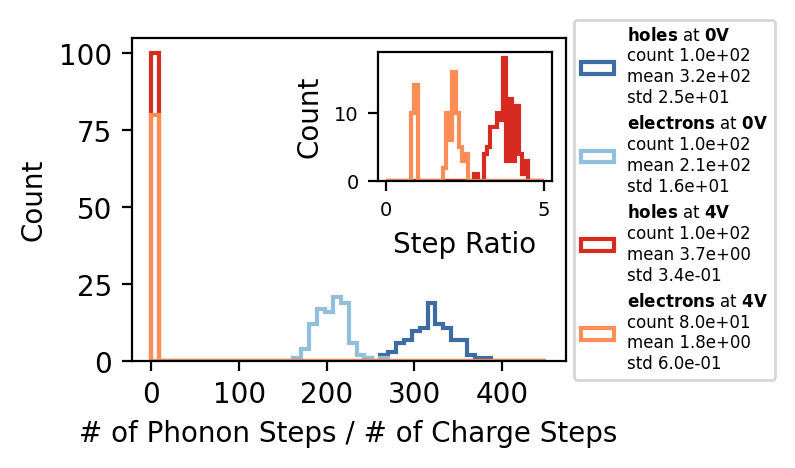

In [6]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
fig, ax = plt.subplots(figsize=(5*0.7,3*0.7), dpi=200)
    
for V in Vs:
    for charge in charges:
        nChargeSteps, nPhononSteps = [], []
        for event in np.unique(data[V][charge]['EventNum']):
            eventCut = data[V][charge]['EventNum'] == event
            phCut = data[V][charge]['Charge'] == 0
            cCut = data[V][charge]['Charge'] != 0
            boundaryCut = (data[V][charge]['Process'] != 'G4CMPChargeBoundary') & (data[V][charge]['Process'] != 'G4CMPPhononBoundary') & (data[V][charge]['Process'] != 'G4CMPChargeRecombine')
            
            nChargeSteps.append(len(data[V][charge]['X1'][eventCut & cCut]))
            nPhononSteps.append(len(data[V][charge]['X1'][eventCut & phCut & boundaryCut]))

        nChargeSteps, nPhononSteps = np.array(nChargeSteps), np.array(nPhononSteps)
        ax.hist(nPhononSteps / nChargeSteps, bins = np.linspace(0, 450, 51), color = colors[V][charge], histtype='step', lw = 1.5, 
                label = (label[V][charge] + "\n" + f"count {len(nPhononSteps / nChargeSteps):.1e}" + "\n" + 
                      f"mean {np.nanmean(nPhononSteps / nChargeSteps):.1e}" +'\n'+
                      f"std {np.nanstd(nPhononSteps / nChargeSteps):.1e}"))
    
ax.set_xlabel('# of Phonon Steps / # of Charge Steps')
ax.set_ylabel('Count')

# Create an inset of the zoomed-in plot
ax_inset = inset_axes(ax, width="40%", height="40%", loc='upper right', borderpad=0.5)
for V in Vs:
    for charge in charges:
        nChargeSteps, nPhononSteps = [], []
        for event in np.unique(data[V][charge]['EventNum']):
            eventCut = data[V][charge]['EventNum'] == event
            phCut = data[V][charge]['Charge'] == 0
            cCut = data[V][charge]['Charge'] != 0
            boundaryCut = (data[V][charge]['Process'] != 'G4CMPChargeBoundary') & (data[V][charge]['Process'] != 'G4CMPPhononBoundary') & (data[V][charge]['Process'] != 'G4CMPChargeRecombine')
            
            nChargeSteps.append(len(data[V][charge]['X1'][eventCut & cCut]))
            nPhononSteps.append(len(data[V][charge]['X1'][eventCut & phCut & boundaryCut]))

        nChargeSteps, nPhononSteps = np.array(nChargeSteps), np.array(nPhononSteps)
        ax_inset.hist(nPhononSteps / nChargeSteps, bins = np.linspace(0, 5, 51), color = colors[V][charge], histtype='step', lw = 1.5, label = label[V][charge])
    
ax_inset.set_xlabel('Step Ratio')
ax_inset.set_ylabel('Count')
ax_inset.tick_params(axis='both', which='major', labelsize=7)

box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=6)

In [43]:
phonons_produced = {V: {charge: [] for charge in charges} for V in Vs}
KE_start = {V: {charge: [] for charge in charges} for V in Vs}

In [44]:
for V in Vs:
    print(V)
    for charge in charges:
        print(charge)
        events = [10, 1][V == '4V']
        for event in np.unique(data[V][charge]['EventNum'])[:events]:
            print(event)
            eventCut = data[V][charge]['EventNum'] == event
            phCut = data[V][charge]['Charge'] == 0
            ParentCut = data[V][charge]['Parent'] == 1
            ProcessCut = data[V][charge]['Process'] == 'G4CMPLukeScattering'
            EmissionTracks = np.unique(data[V][charge]['TrkStep'][eventCut & phCut & ParentCut & ProcessCut] // 100000)

            for Emission in EmissionTracks:
                phonons = 1 # one phonon emitted from Luke scatter
                ParentCut = data[V][charge]['Parent'] == Emission
                TrkCut = data[V][charge]['TrkStep'] // 100000 == Emission
                KE_start[V][charge].append(data[V][charge]['KE'][eventCut & TrkCut][0])
                while(any(ParentCut)):
                    secondaries = np.unique(data[V][charge]['TrkStep'][eventCut & phCut & ParentCut] // 100000)
                    phonons += len(secondaries) # add number of secondaries
                    ParentCut = np.full(len(data[V][charge]['Parent']), False)
                    for Trk in secondaries:
                        ParentCut = ParentCut | (data[V][charge]['Parent'] == Trk)

                phonons_produced[V][charge].append(phonons)

0V
h
0.0
1.0
2.0
3.0
4.0
5.0
6.0
7.0
8.0
9.0
e
0.0
1.0
2.0
3.0
4.0
5.0
6.0
7.0
8.0
9.0
4V
h
0.0
e
0.0


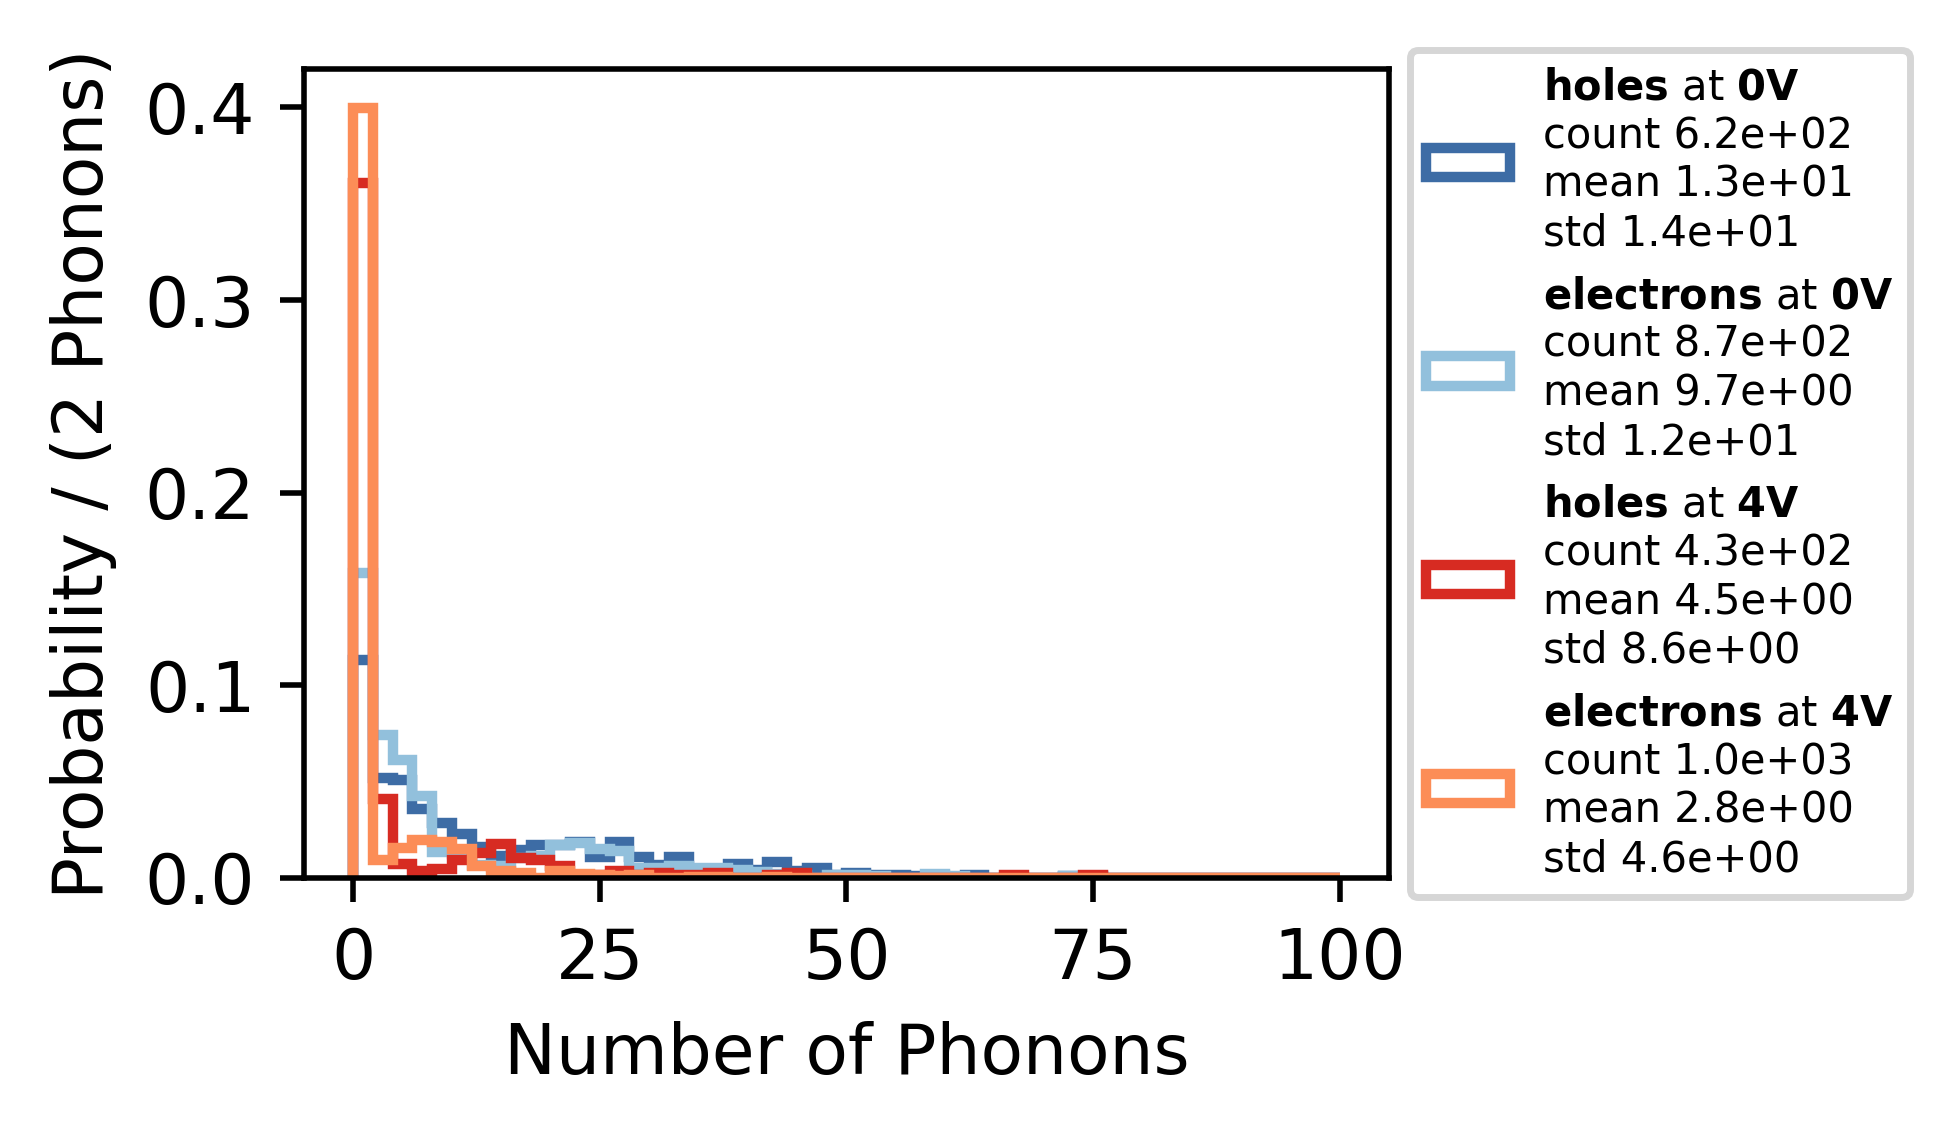

In [45]:
fig = plt.figure(figsize=(5*0.7,3*0.7), dpi = 500)
ax = plt.subplot(111)

for V in Vs:
    for charge in charges:
        ax.hist(phonons_produced[V][charge], bins = np.linspace(0, 100, 51), color = colors[V][charge], histtype='step', lw=1.5, density = True,
                 label = (label[V][charge] + "\n" + f"count {len(phonons_produced[V][charge]):.1e}" + "\n" + 
                          f"mean {np.nanmean(phonons_produced[V][charge]):.1e}" +'\n'+
                          f"std {np.nanstd(phonons_produced[V][charge]):.1e}"))

ax.set_xlabel('Number of Phonons')
ax.set_ylabel('Probability / (2 Phonons)')
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=6)

/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


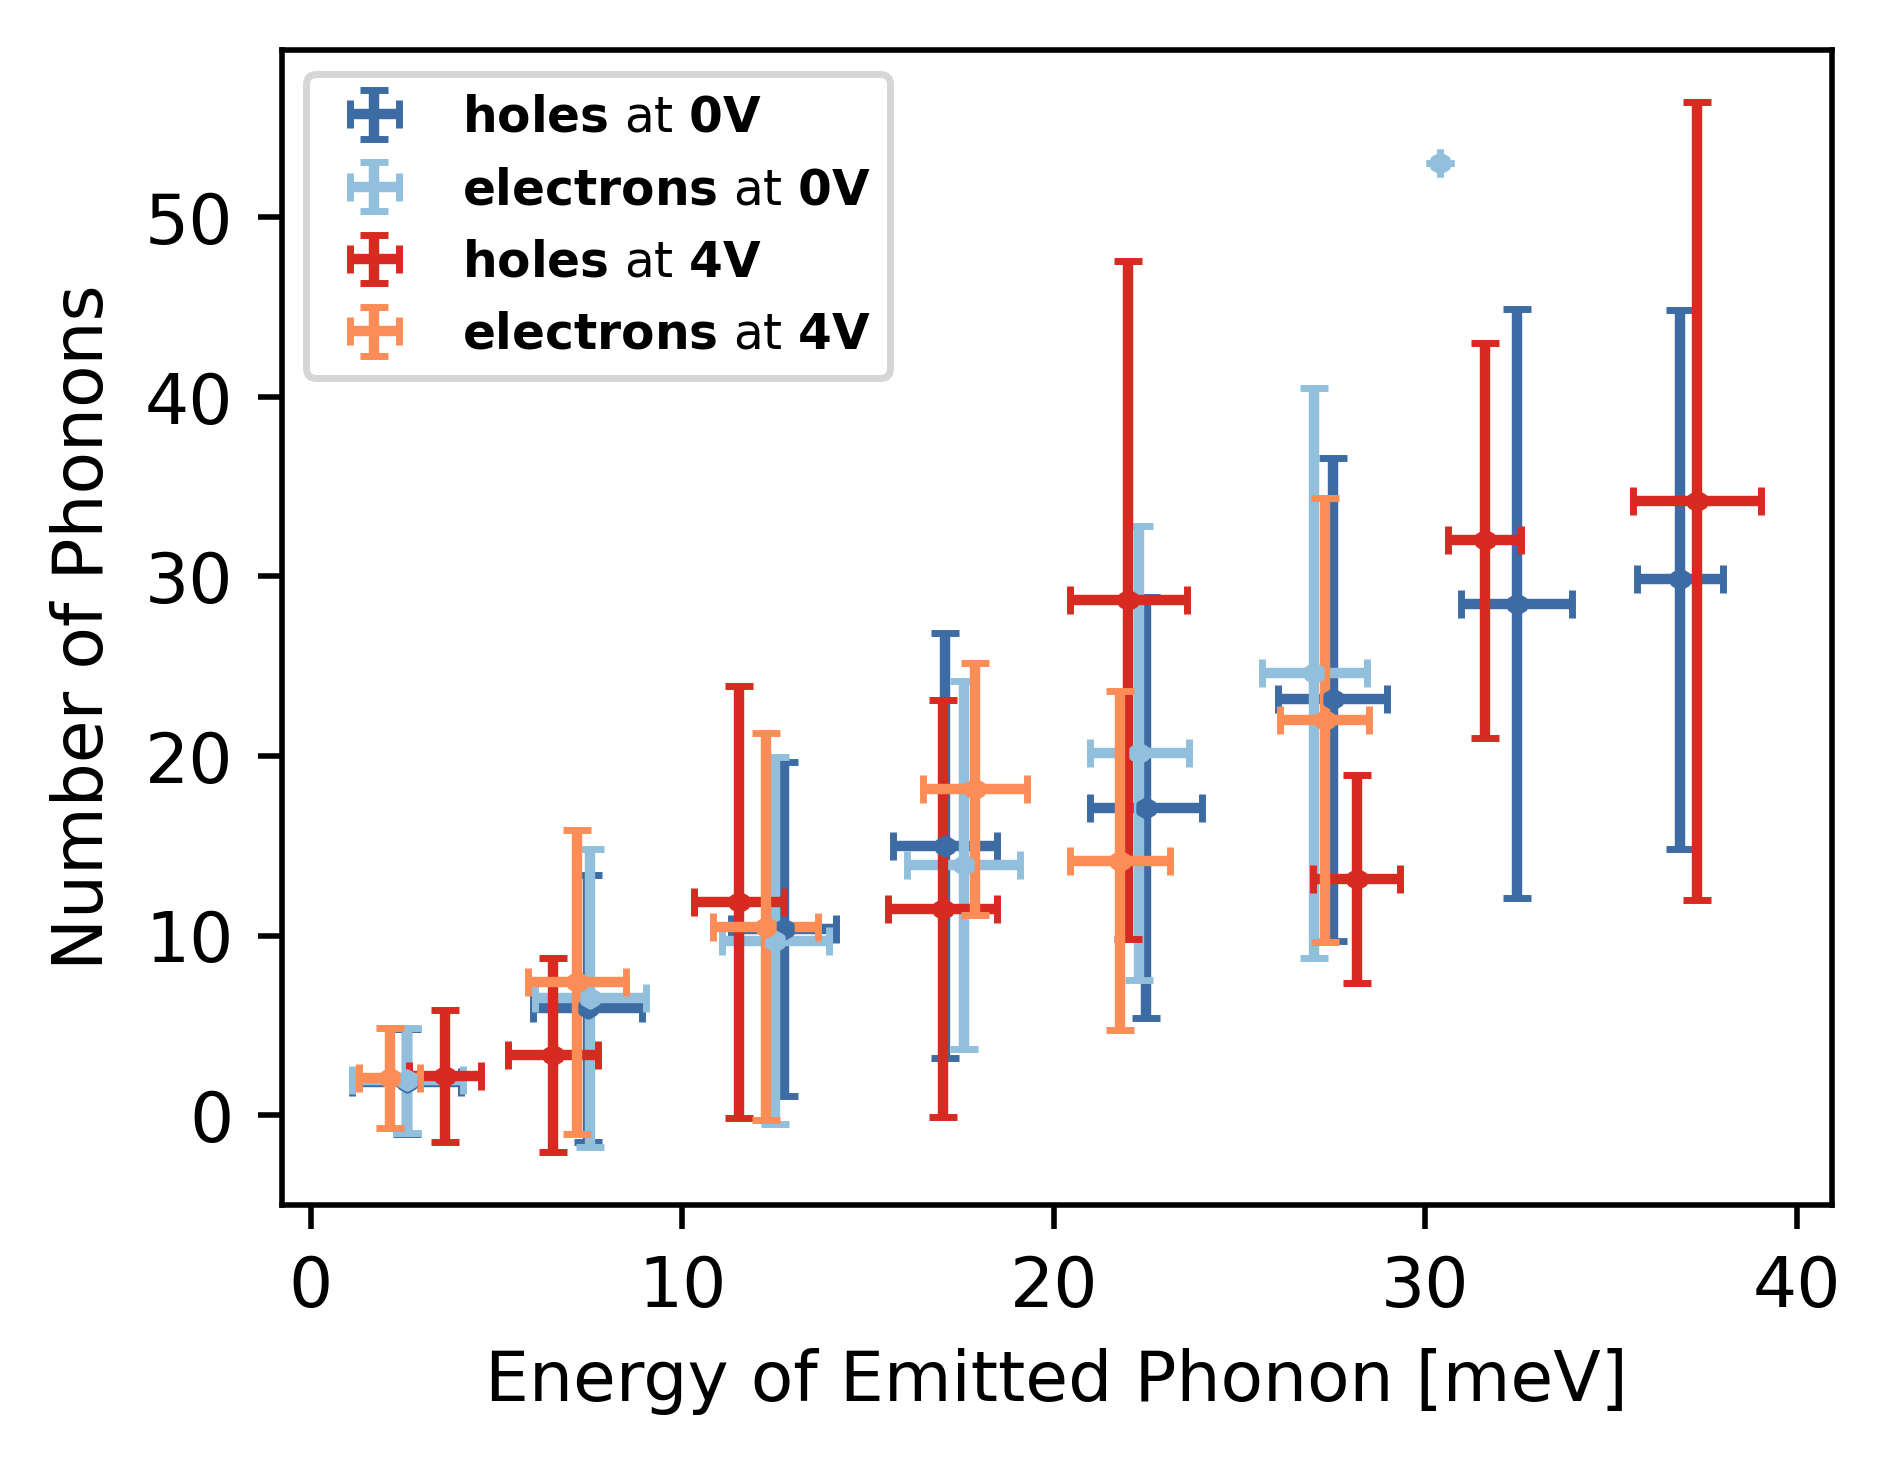

In [46]:
fig = plt.figure(figsize=(4,3), dpi = 500)
ax = plt.subplot(111)

for V in Vs:
    for charge in charges:
        KE_start[V][charge] = np.array(KE_start[V][charge])
        phonons_produced[V][charge] = np.array(phonons_produced[V][charge])
        KE_bins = np.arange(0, 0.04 + 0.005, 0.005)
        KE_mean, KE_std = [], []
        num_mean, num_std = [], []
        for step in range(len(KE_bins)):
            KE_cut = (KE_start[V][charge] > KE_bins[step - 1]) & (KE_start[V][charge] < KE_bins[step])
            KE_mean.append(np.mean(KE_start[V][charge][KE_cut]))
            KE_std.append(np.std(KE_start[V][charge][KE_cut]))
            num_mean.append(np.mean(phonons_produced[V][charge][KE_cut]))
            num_std.append(np.std(phonons_produced[V][charge][KE_cut]))

        ax.errorbar(np.array(KE_mean)*1e3, num_mean, xerr = np.array(KE_std)*1e3, yerr = num_std, ls = "None", 
                    color=colors[V][charge], capsize = 2, label = label[V][charge])
        ax.scatter(np.array(KE_mean)*1e3, num_mean, s = 5, marker = "h", color = colors[V][charge], zorder=10)

ax.set_xlabel('Energy of Emitted Phonon [meV]')
ax.set_ylabel('Number of Phonons')
ax.legend(loc='upper left', fontsize = 7)